<a href="https://colab.research.google.com/github/SmitSutariya0205/GCN-Based-DCR-Prediction-and-FRP-Recommendation/blob/main/gcn_dcr_prediction_and_frp_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
uploaded = files.upload()

Saving FRP_DCR_Data.xlsx to FRP_DCR_Data (1).xlsx


In [3]:
df_cases = pd.read_excel('FRP_DCR_Data.xlsx', sheet_name=0)
df_main = pd.read_excel('FRP_DCR_Data.xlsx', sheet_name=1)

In [4]:
DCR = df_main.iloc[:, 7:270].values   # exclude Current DCR
y_cases = DCR.T                       # (263, 61)

In [5]:
df_cases.columns

Index(['Case No.\n(Data Set No.)', 'Fiber\nThickness (mm)',
       'Tensile\nStrength (N/mm2)', 'Tensile\nModulus (N/mm2)',
       'Elongation (%)', 'Direction', 'Fiber\nOrientation',
       'Number\nof Layers'],
      dtype='object')

In [6]:
X_num = df_cases[['Fiber\nThickness (mm)',
                  'Tensile\nStrength (N/mm2)',
                  'Tensile\nModulus (N/mm2)',
                  'Elongation (%)',
                  'Number\nof Layers']].values

In [7]:
# Categorical → One-hot
X_cat = pd.get_dummies(df_cases[['Direction', 'Fiber\nOrientation']])


In [8]:
# Combine
X_cases = np.hstack([X_num, X_cat.values])

In [9]:
scaler = StandardScaler()
X_cases = scaler.fit_transform(X_cases)

In [10]:
geom = df_main[['L\n(in mm)',
                'D\n(in mm)',
                'b\n(in mm)',
                'Current DCR']].values

In [11]:
print(geom.shape)

(61, 4)


In [12]:
from sklearn.preprocessing import StandardScaler
scaler_geom = StandardScaler()
geom = scaler_geom.fit_transform(geom)

In [13]:
print(geom[0])

[-1.4605356  -1.2        -1.2        -0.65445236]


In [14]:
node_features_list=[]
num_cases=X_cases.shape[0]
num_nodes=geom.shape[0]
for i in range (num_cases):
    #repeat frp featires for all nodes
    X_nodes=np.tile(X_cases[i],(num_nodes,1))
    #combine with  geometry to mske it unique per node
    x_combined=np.hstack([X_nodes,geom])
    node_features_list.append(x_combined)


In [15]:
print(node_features_list[0].shape)

(61, 12)


In [16]:
import torch
node_features_list=[
    torch.tensor(x,dtype=torch.float32)
    for x in node_features_list
]
# convert labels
y_cases=torch.tensor(y_cases,dtype=torch.float32)

In [17]:
print(df_main['Element Name'].head(20))

0      C1
1      C2
2      C3
3      C4
4      C5
5      C6
6      C7
7      C8
8      C9
9     C10
10    C11
11    C12
12    C13
13    C14
14    C15
15    C16
16    C17
17    C18
18    C19
19    C27
Name: Element Name, dtype: object


In [18]:
#lets create a node to idx mapping
node_names=df_main["Element Name"].values
node_to_idx={name:i for i,name in enumerate(node_names)}

In [19]:
print(node_to_idx['C22'])

45


In [20]:
print(len(node_names))

61


In [21]:
num_nodes=len(node_names)

In [22]:
A=torch.zeros(num_nodes,num_nodes,dtype=torch.float32)

In [23]:
edges = [

    #  Left vertical column
    ('C1','C2'), ('C2','C3'), ('C3','C4'),
    #  Bottom horizontal spine
    ('C4','C6'), ('C6','C8'), ('C8','C10'),
    ('C10','C13'), ('C13','C16'), ('C16','C19'),
    #  Vertical connectors(left-mid columns)
    ('C5','C6'), ('C7','C8'), ('C9','C10'),
    #  Right block-vertical connections
    ('C11','C12'), ('C12','C13'),
    ('C14','C15'), ('C15','C16'),
    ('C17','C18'), ('C18','C19'),
    #  Right block-horizontal(top row)
    ('C11','C14'), ('C14','C17'),
    #  Right block-horizontal (middle row)
    ('C12','C15'), ('C15','C18'),
    #  Right block-horizontal(bottom row)
    ('C13','C16'), ('C16','C19'),
]
# Top beam
edges += [
    ('C1','C5'),
    ('C5','C7'),
    ('C7','C9'),
    ('C9','C11')
]

# Middle beam
edges += [
    ('C12','C15'),
    ('C15','C18')
]

In [24]:
edges_first=[]
for n1,n2 in edges:
    c1=int(n1[1:])
    c2=int(n2[1:])
    edges_first.append((f'C{c1+19}',f'C{c2+19}'))

In [25]:
edges_second =[]
for n1, n2 in edges:
    c1 =int(n1[1:])
    c2 =int(n2[1:])

    edges_second.append((f'C{c1+38}', f'C{c2+38}'))

In [26]:
edges

[('C1', 'C2'),
 ('C2', 'C3'),
 ('C3', 'C4'),
 ('C4', 'C6'),
 ('C6', 'C8'),
 ('C8', 'C10'),
 ('C10', 'C13'),
 ('C13', 'C16'),
 ('C16', 'C19'),
 ('C5', 'C6'),
 ('C7', 'C8'),
 ('C9', 'C10'),
 ('C11', 'C12'),
 ('C12', 'C13'),
 ('C14', 'C15'),
 ('C15', 'C16'),
 ('C17', 'C18'),
 ('C18', 'C19'),
 ('C11', 'C14'),
 ('C14', 'C17'),
 ('C12', 'C15'),
 ('C15', 'C18'),
 ('C13', 'C16'),
 ('C16', 'C19'),
 ('C1', 'C5'),
 ('C5', 'C7'),
 ('C7', 'C9'),
 ('C9', 'C11'),
 ('C12', 'C15'),
 ('C15', 'C18')]

In [27]:
edges_vertical = []

for i in range(1, 20):
    edges_vertical.append((f'C{i}',f'C{i+19}'))
    edges_vertical.append((f'C{i+19}',f'C{i+38}'))

In [28]:
all_edges = edges+edges_first+edges_second+edges_vertical

In [29]:
#creating the adj matrix
for n1, n2 in all_edges:
    i = node_to_idx[n1]
    j = node_to_idx[n2]
    A[i, j] = 1
    A[j, i] = 1

In [30]:
##next step-->Normalize adjacency
A.shape

torch.Size([61, 61])

In [31]:
node_features_list[0].shape[1]

12

In [32]:
#add self loops
I =torch.eye(A.shape[0])
A_hat=A+I

In [33]:
D=torch.diag(torch.sum(A_hat,dim=1))
D_inv_sqrt=torch.inverse(torch.sqrt(D))
A_norm=D_inv_sqrt @ A_hat @ D_inv_sqrt

In [34]:
import torch.nn as nn
class GCNLayer(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()
        self.linear=nn.Linear(in_features,out_features)
    def forward(self,X,A):
        return self.linear(A @ X)

In [35]:
class GCN(nn.Module):
    def __init__(self,in_features):
        super().__init__()
        self.gcn1=GCNLayer(in_features,32)
        self.gcn2=GCNLayer(32,1)
    def forward(self,X,A):
        h=self.gcn1(X,A)
        h = torch.relu(h)
        h = self.gcn2(h, A)
        return torch.relu(h).squeeze()

In [36]:
#Initialize the model (structure)
model=GCN(in_features=node_features_list[0].shape[1])
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)
loss_fn=nn.MSELoss()

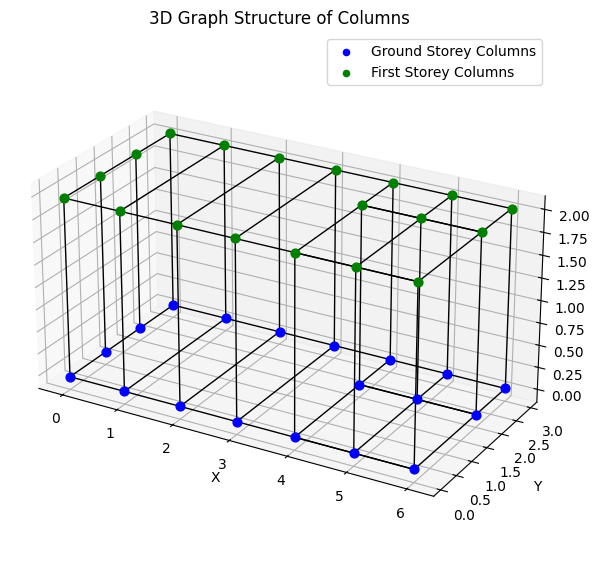

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
x_coords = [0, 1, 2, 3, 4, 5, 6]
y_coords = [0, 1, 2, 3]
z_plinth = 0
z_first = 2
layout = {
    # left vertical
    'C1': (0,3), 'C2': (0,2), 'C3': (0,1), 'C4': (0,0),

    # bottom row
    'C6': (1,0), 'C8': (2,0), 'C10': (3,0),
    'C13': (4,0), 'C16': (5,0), 'C19': (6,0),

    # middle row
    'C5': (1,3), 'C7': (2,3), 'C9': (3,3),

    # right grid
    'C11': (4,3), 'C14': (5,3), 'C17': (6,3),
    'C12': (4,2), 'C15': (5,2), 'C18': (6,2),
}
node_positions = {}
# plinth
for node, (xi, yi) in layout.items():
    node_positions[node] = [x_coords[xi], y_coords[yi], z_plinth]
# first floor
for i in range(1, 20):
    base = f'C{i}'
    if base in node_positions:
        x, y, _ = node_positions[base]
        node_positions[f'C{i+19}'] = [x, y, z_first]
edges_plot = [
    (n1, n2) for (n1, n2) in all_edges
    if int(n1[1:]) <= 38 and int(n2[1:]) <= 38
]
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
# nodes
for node, (x, y, z) in node_positions.items():
    num = int(node[1:])

    if num <= 19:
        ax.scatter(x, y, z, color='blue', s=40)
    else:
        ax.scatter(x, y, z, color='green', s=40)
# edges
for n1, n2 in edges_plot:
    if n1 in node_positions and n2 in node_positions:
        x_vals = [node_positions[n1][0], node_positions[n2][0]]
        y_vals = [node_positions[n1][1], node_positions[n2][1]]
        z_vals = [node_positions[n1][2], node_positions[n2][2]]
        ax.plot(x_vals, y_vals, z_vals, color='black', linewidth=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_box_aspect([2,1,1])   # same proportions
ax.view_init(elev=25, azim=-60)  # match angle
# legend
ax.scatter([], [], [], color='blue', label='Ground Storey Columns')
ax.scatter([], [], [], color='green', label='First Storey Columns')
ax.legend()
plt.title("3D Graph Structure of Columns")
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
import numpy as np
indices=np.arange(len(node_features_list))

In [39]:
train_idx,temp_idx=train_test_split(indices,test_size=0.2,random_state=42)

In [40]:
val_idx,test_idx=train_test_split(temp_idx,test_size=0.5,random_state=42)

In [41]:
# train-val-test splits
x_train=[node_features_list[i] for i in train_idx]
y_train=y_cases[train_idx]
x_val = [node_features_list[i] for i in val_idx]
y_val = y_cases[val_idx]
x_test = [node_features_list[i] for i in test_idx]
y_test = y_cases[test_idx]

In [42]:
train_loses=[]
val_loses=[]
epochs=500
for epoch in range (epochs):
    model.train()
    train_loss=0
    for x,y in zip(x_train,y_train):
        pred=model(x,A_norm)
        loss=loss_fn(pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()

    train_loss/=len(x_train)
    train_loses.append(train_loss)

    model.eval()
    val_loss=0

    with torch.no_grad():
        for x,y in zip(x_val,y_val):
            pred=model(x,A_norm)
            loss=loss_fn(pred,y)
            val_loss+=loss.item()

    val_loss/=len(x_val)
    val_loses.append(val_loss)

    print(f"Epoch{epoch+1}, Train: {train_loss:.4f}, Val: {val_loss:.4f}")



Epoch1, Train: 0.3403, Val: 0.2165
Epoch2, Train: 0.2323, Val: 0.1968
Epoch3, Train: 0.2194, Val: 0.1889
Epoch4, Train: 0.2113, Val: 0.1831
Epoch5, Train: 0.2072, Val: 0.1785
Epoch6, Train: 0.2041, Val: 0.1751
Epoch7, Train: 0.2006, Val: 0.1726
Epoch8, Train: 0.1974, Val: 0.1697
Epoch9, Train: 0.1950, Val: 0.1681
Epoch10, Train: 0.1935, Val: 0.1658
Epoch11, Train: 0.1925, Val: 0.1654
Epoch12, Train: 0.1912, Val: 0.1641
Epoch13, Train: 0.1899, Val: 0.1643
Epoch14, Train: 0.1889, Val: 0.1620
Epoch15, Train: 0.1871, Val: 0.1622
Epoch16, Train: 0.1866, Val: 0.1610
Epoch17, Train: 0.1854, Val: 0.1601
Epoch18, Train: 0.1844, Val: 0.1593
Epoch19, Train: 0.1843, Val: 0.1585
Epoch20, Train: 0.1824, Val: 0.1568
Epoch21, Train: 0.1796, Val: 0.1523
Epoch22, Train: 0.1771, Val: 0.1556
Epoch23, Train: 0.1749, Val: 0.1519
Epoch24, Train: 0.1723, Val: 0.1498
Epoch25, Train: 0.1706, Val: 0.1524
Epoch26, Train: 0.1693, Val: 0.1559
Epoch27, Train: 0.1679, Val: 0.1568
Epoch28, Train: 0.1655, Val: 0.1606
E

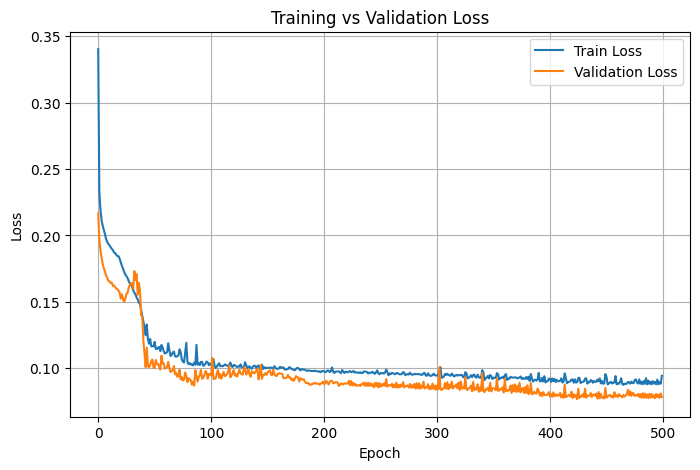

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_loses, label='Train Loss')
plt.plot(val_loses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [44]:
model.eval()

test_mse = []

with torch.no_grad():
    for x, y in zip(x_test, y_test):
        pred = model(x, A_norm)
        pred_np = pred.numpy()
        true_np = y.numpy()
        test_mse.append(np.mean((pred_np - true_np)**2))
print("FINAL Test MSE:", np.mean(test_mse))

FINAL Test MSE: 0.0956085


In [45]:
weights = model.gcn1.linear.weight.detach().numpy()
feature_importance = np.mean(np.abs(weights), axis=0)
feature_importance = feature_importance / np.sum(feature_importance)

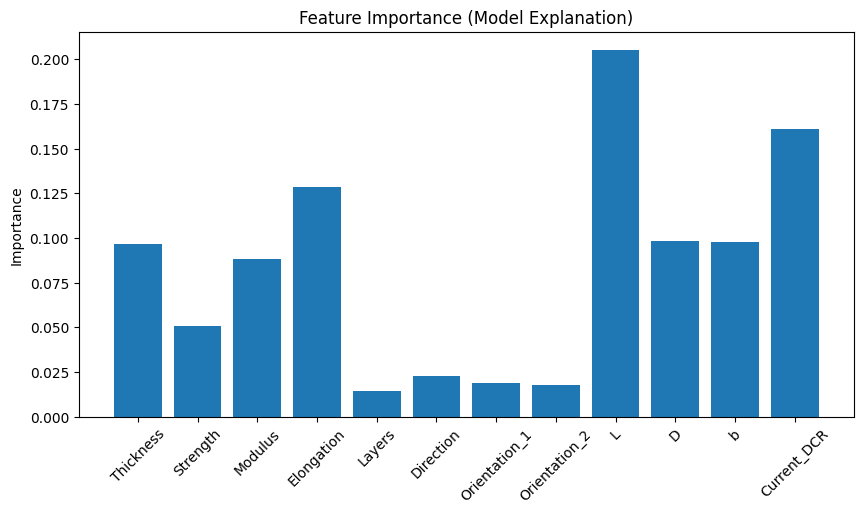

In [46]:
import matplotlib.pyplot as plt
feature_names = [
    'Thickness',
    'Strength',
    'Modulus',
    'Elongation',
    'Layers',
    'Direction',
    'Orientation_1',
    'Orientation_2',
    'L',
    'D',
    'b',
    'Current_DCR'
]
plt.figure(figsize=(10,5))
plt.bar(feature_names, feature_importance)
plt.xticks(rotation=45)
plt.title("Feature Importance (Model Explanation)")
plt.ylabel("Importance")
plt.show()

In [47]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [48]:
import pandas as pd
model.eval()
X = x_test[0]
y_true = y_test[0]
with torch.no_grad():
    y_pred = model(X, A_norm)

y_true_np = y_true.numpy()
y_pred_np = y_pred.numpy()

node_ids = [f'C{i+1}' for i in range(len(y_true_np))]

df = pd.DataFrame({
    'Node': node_ids,
    'Actual_DCR': y_true_np,
    'Predicted_DCR': y_pred_np,
    'Error': abs(y_true_np - y_pred_np)
})
df = df.round(3)
df = df.sort_values(by='Actual_DCR', ascending=False)

print(df.to_string(index=False))

Node  Actual_DCR  Predicted_DCR  Error
  C5       2.575          2.024  0.551
  C4       2.450          2.235  0.215
  C2       2.437          1.980  0.457
  C7       2.162          2.051  0.111
 C21       2.026          1.401  0.624
  C3       1.993          1.981  0.012
 C22       1.901          1.273  0.628
  C6       1.739          2.341  0.602
  C1       1.675          2.041  0.366
 C20       1.558          1.008  0.550
 C18       1.337          1.217  0.120
 C25       1.279          1.165  0.114
 C15       1.252          1.195  0.057
  C8       1.153          1.403  0.250
 C10       1.146          1.467  0.320
 C12       1.142          1.167  0.024
 C13       1.108          1.094  0.014
 C11       1.085          1.033  0.052
  C9       0.999          1.393  0.394
 C31       0.993          1.156  0.163
 C19       0.990          0.994  0.004
 C16       0.958          1.348  0.390
 C24       0.941          0.941  0.001
 C14       0.927          0.842  0.085
 C32       0.869         

In [49]:
# Set column ID
df_main.set_index("Element Name", inplace=True)

# Extract case columns only
dcr_df = df_main.loc[:, "Case #1":]

print(dcr_df.shape)

(61, 263)


In [50]:
dcr_df.head()

,Case #1,Case #2,Case #3,Case #4,Case #5,Case #6,Case #7,Case #8,Case #9,Case #10,Case #11,Case #12,Case #13,Case #14,Case #15,Case #16,Case #17,Case #18,Case #19,Case #20,Case #21,Case #22,Case #23,Case #24,Case #25,Case #26,Case #27,Case #28,Case #29,Case #30,Case #31,Case #32,Case #33,Case #34,Case #35,Case #36,Case #37,Case #38,Case #39,Case #40,Case #41,Case #42,Case #43,Case #44,Case #45,Case #46,Case #47,Case #48,Case #49,Case #50,Case #51,Case #52,Case #53,Case #54,Case #55,Case #56,Case #57,Case #58,Case #59,Case #60,Case #61,Case #62,Case #63,Case #64,Case #65,Case #66,Case #67,Case #68,Case #69,Case #70,Case #71,Case #72,Case #73,Case #74,Case #75,Case #76,Case #77,Case #78,Case #79,Case #80,Case #81,Case #82,Case #83,Case #84,Case #85,Case #86,Case #87,Case #88,Case #89,Case #90,Case #91,Case #92,Case #93,Case #94,Case #95,Case #96,Case #97,Case #98,Case #99,Case #100,Case #101,Case #102,Case #103,Case #104,Case #105,Case #106,Case #107,Case #108,Case #109,Case #110,Case #111,Case #112,Case #113,Case #114,Case #115,Case #116,Case #117,Case #118,Case #119,Case #120,Case #121,Case #122,Case #123,Case #124,Case #125,Case #126,Case #127,Case #128,Case #129,Case #130,Case #131,Case #132,Case #133,Case #134,Case #135,Case #136,Case #137,Case #138,Case #139,Case #140,Case #141,Case #142,Case #143,Case #144,Case #145,Case #146,Case #147,Case #148,Case #149,Case #150,Case #151,Case #152,Case #153,Case #154,Case #155,Case #156,Case #157,Case #158,Case #159,Case #160,Case #161,Case #162,Case #163,Case #164,Case #165,Case #166,Case #167,Case #168,Case #169,Case #170,Case #171,Case #172,Case #173,Case #174,Case #175,Case #176,Case #177,Case #178,Case #179,Case #180,Case #181,Case #182,Case #183,Case #184,Case #185,Case #186,Case #187,Case #188,Case #189,Case #190,Case #191,Case #192,Case #193,Case #194,Case #195,Case #196,Case #197,Case #198,Case #199,Case #200,Case #201,Case #202,Case #203,Case #204,Case #205,Case #206,Case #207,Case #208,Case #209,Case #210,Case #211,Case #212,Case #213,Case #214,Case #215,Case #216,Case #217,Case #218,Case #219,Case #220,Case #221,Case #222,Case #223,Case #224,Case #225,Case #226,Case #227,Case #228,Case #229,Case #230,Case #231,Case #232,Case #233,Case #234,Case #235,Case #236,Case #237,Case #238,Case #239,Case #240,Case #241,Case #242,Case #243,Case #244,Case #245,Case #246,Case #247,Case #248,Case #249,Case #250,Case #251,Case #252,Case #253,Case #254,Case #255,Case #256,Case #257,Case #258,Case #259,Case #260,Case #261,Case #262,Case #263
Element Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
C1,1.734230,1.732496,1.731629,1.730761,1.729894,1.729027,1.728160,1.727293,1.726426,1.725559,1.724692,1.723825,1.722957,1.722090,1.721223,1.720356,1.719489,1.718622,1.717755,1.716888,1.716021,1.715153,1.714286,1.713419,1.712552,1.711685,1.710818,1.709951,1.709084,1.708216,1.707349,1.706482,1.705615,1.704748,1.703881,1.703014,1.702147,1.701280,1.700412,1.699545,1.698678,1.697811,1.696944,1.696077,1.695210,1.694343,1.693476,1.692608,1.691741,1.690874,1.690007,1.689140,1.688273,1.687406,1.686539,1.685671,1.684804,1.683937,1.683070,1.682203,1.681336,1.680469,1.679602,1.678735,1.677867,1.677000,1.676133,1.675266,1.674399,1.673532,1.672665,1.671798,1.670931,1.670063,1.669196,1.668329,1.667462,1.666595,1.665728,1.664861,1.663994,1.663126,1.662259,1.661392,1.660525,1.659658,1.658791,1.657924,1.657057,1.656190,1.655322,1.654455,1.653588,1.652721,1.651854,1.650987,1.650120,1.649253,1.648386,1.647518,1.646651,1.645784,1.644917,1.644050,1.643183,1.642316,1.641449,1.640582,1.639714,1.638847,1.637980,1.637113,1.636246,1.635379,1.634512,1.633645,1.632777,1.631910,1.631043,1.630176,1.629309,1.628442,1.627575,1.626708,1.625841,1.624973,1.624106,1.623239,1.622372,1.621505,1.620638,1.619771,1.618904,1

In [51]:
print(df_cases.head())

  Case No.\n(Data Set No.)  Fiber\nThickness (mm)  Tensile\nStrength (N/mm2)  \
0                  Case #1                  0.129                       4000   
1                  Case #2                  0.129                       4000   
2                  Case #3                  0.129                       4000   
3                  Case #4                  0.129                       4000   
4                  Case #5                  0.129                       4000   

   Tensile\nModulus (N/mm2)  Elongation (%)       Direction  \
0                    230000             1.7  Unidirectional   
1                    230000             1.7  Unidirectional   
2                    230000             1.7  Unidirectional   
3                    230000             1.7  Unidirectional   
4                    230000             1.7  Unidirectional   

  Fiber\nOrientation  Number\nof Layers  
0                 0°                  1  
1                 0°                  2  
2             

In [52]:
frp_df = df_cases.copy()
frp_df.columns = [col.replace("\n", " ").strip() for col in frp_df.columns]
print(frp_df.columns)

Index(['Case No. (Data Set No.)', 'Fiber Thickness (mm)',
       'Tensile Strength (N/mm2)', 'Tensile Modulus (N/mm2)', 'Elongation (%)',
       'Direction', 'Fiber Orientation', 'Number of Layers'],
      dtype='object')


In [53]:
frp_df = frp_df.iloc[:, 1:]
frp_df = frp_df.reset_index(drop=True)

In [60]:
def recommend_frp_from_db(column_name, frp_df, dcr_df):

    column_dcr_values = dcr_df.loc[column_name].values

    results_safe = []
    results_all = []

    for i, dcr in enumerate(column_dcr_values):
        config = frp_df.iloc[i]
        results_all.append((config, dcr))
        if dcr < 1.0:
            results_safe.append((config, dcr))

    # Case 1
    if len(results_safe) > 0:

        def sort_key(item):
            config, dcr = item
            thickness = config["Fiber Thickness (mm)"]
            layers = config["Number of Layers"]
            return (layers, thickness, dcr)

        results_sorted = sorted(results_safe, key=sort_key)
        return results_sorted[0], "SAFE"

    # Case 2
    else:
        # choose minimum DCR
        best = min(results_all, key=lambda x: x[1])
        return best, "NOT SAFE (Best Possible)"

In [61]:
def display_result(result):

    (config, dcr), status = result

    print("\n Recommendation Status:", status)

    print("\n Recommended FRP Configuration:\n")

    print(f"Fiber Thickness   : {config['Fiber Thickness (mm)']} mm")
    print(f"Tensile Strength  : {config['Tensile Strength (N/mm2)']}")
    print(f"Tensile Modulus   : {config['Tensile Modulus (N/mm2)']}")
    print(f"Elongation        : {config['Elongation (%)']} %")
    print(f"Direction         : {config['Direction']}")
    print(f"Orientation       : {config['Fiber Orientation']}")
    print(f"Layers            : {config['Number of Layers']}")

    print(f"\n Achieved DCR   : {round(dcr, 3)}")

In [64]:
# we test here
column_name = "C12"
result = recommend_frp_from_db(column_name, frp_df, dcr_df)
display_result(result)


 Recommendation Status: SAFE

 Recommended FRP Configuration:

Fiber Thickness   : 0.33 mm
Tensile Strength  : 3500
Tensile Modulus   : 225000
Elongation        : 2.1 %
Direction         : Unidirectional
Orientation       : 90°
Layers            : 1

 Achieved DCR   : 0.995
